<a href="https://colab.research.google.com/github/MinThuKhant763/machine-learning/blob/main/Linear_Regression_Using_Mean_Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/Admission_Predict.csv')

df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [28]:
df.tail()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67
399,400,333,117,4,5.0,4.0,9.66,1,0.95


In [29]:
df.drop("Serial No.",axis=1,inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [30]:
y = df["Chance of Admit "]
df.drop("Chance of Admit ",axis=1,inplace=True)

In [31]:
print(y.head())

0    0.92
1    0.76
2    0.72
3    0.80
4    0.65
Name: Chance of Admit , dtype: float64


In [32]:
from sklearn.preprocessing import FunctionTransformer
import numpy as np
def mean_normalization(X):
  return (X-np.mean(X,axis=0))/(np.max(X,axis=0)-np.min(X,axis=0))

In [33]:
mean_norm = FunctionTransformer(mean_normalization)
df_mn = mean_norm.fit_transform(df)

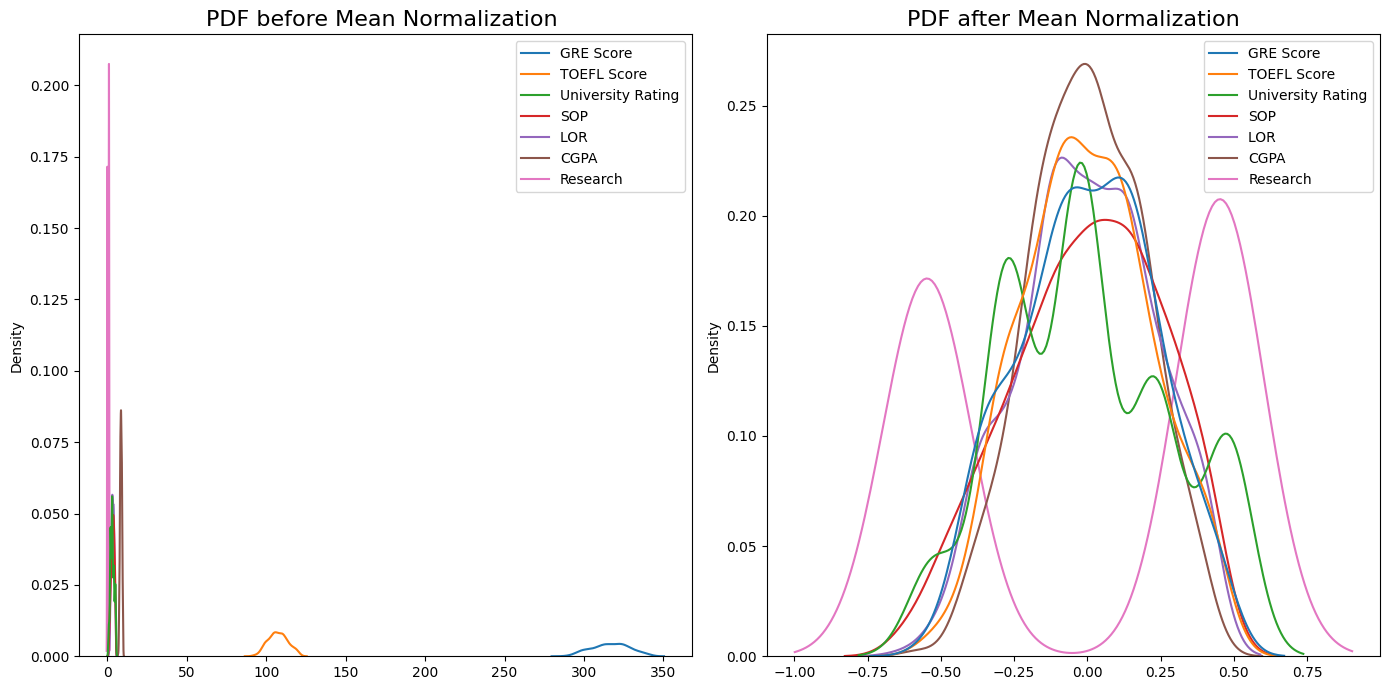

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("PDF before Mean Normalization ",fontsize=16)
sns.kdeplot(data=df,color="blue")
plt.subplot(1,2,2)
plt.title("PDF after Mean Normalization",fontsize=16)
sns.kdeplot(data=df_mn,color="red")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df_mn,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)
pred = lr.predict(x_test)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,pred))
print("Root Mean Squared Error (Using Mean Normalization)",rmse)


Root Mean Squared Error (Using Mean Normalization) 0.06794853476922821
